In [1]:
%autoreload 2
%matplotlib ipympl
import os
import glob
import re 
import numpy as np
import matplotlib.pyplot as plt
from qwfs.qwfs_result import QWFSResult
from qwfs.qwfs_simulation import QWFSSimulation

DATA_DIR = os.path.join(os.path.abspath(os.path.curdir), 'data')

# 1) Assert analytic results agree with autograd-BFGS

## 1.1 the actual found phases are the same
The optimizer finds close to optimal phases for the relevant sizes of the system we consider. In most of the paper we work with N=512 to avoid long run times. 

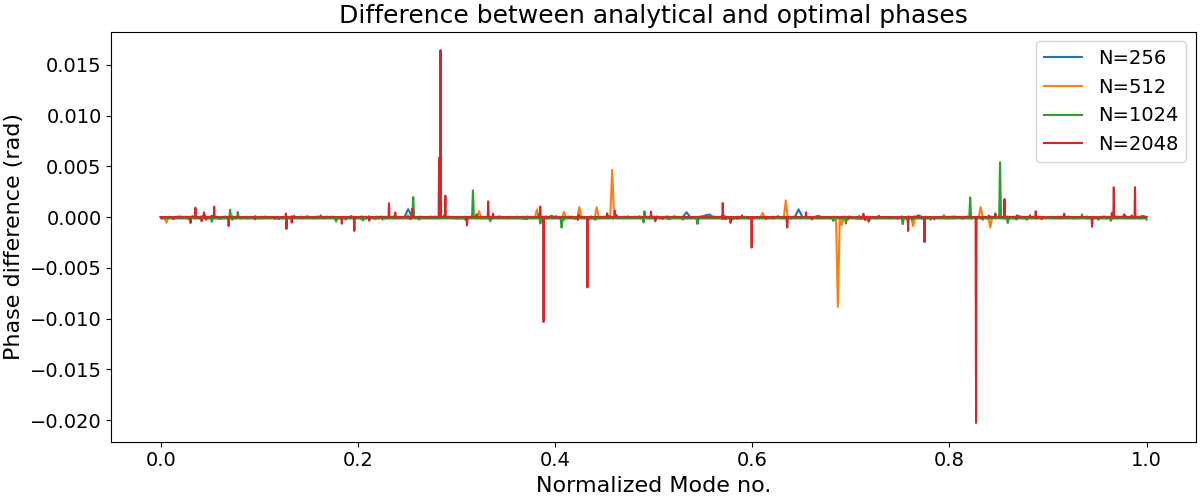

In [34]:
path256 = glob.glob(rf'{DATA_DIR}\vrs_analytic\*256*')[0]
path512 = glob.glob(rf'{DATA_DIR}\vrs_analytic\*512*')[0]
path1024 = glob.glob(rf'{DATA_DIR}\vrs_analytic\*1024*')[0]
path2048 = glob.glob(rf'{DATA_DIR}\vrs_analytic\*2048*')[0]
res256 = QWFSResult(path256)
res512 = QWFSResult(path512)
res1024 = QWFSResult(path1024)
res2048 = QWFSResult(path2048)

T_method = 'unitary'
config = 'SLM2-simple'
try_no = 0

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
for res in [res256, res512, res1024, res2048]:
    phases_analytic = res.get_phases(config=config, T_method=T_method, alg='analytic', try_no=try_no)
    phases_adam = res.get_phases(config=config, T_method=T_method, alg='autograd-lbfgs', try_no=try_no)

    phases_analytic -= phases_analytic[0]
    phases_adam -= phases_adam[0]
    
    phases_analytic = phases_analytic % (2*np.pi)
    phases_adam = phases_adam % (2*np.pi)
    X = np.linspace(0, 1, len(phases_analytic))
    ax.plot(X, phases_analytic - phases_adam, label=f'N={res.N_modes}')
ax.legend(fontsize=14)
ax.set_xlabel('Normalized Mode no.', fontsize=16)
ax.set_ylabel('Phase difference (rad)', fontsize=16)
ax.set_title('Difference between analytical and optimal phases', fontsize=18)
ax.tick_params(axis='both', labelsize=14)  # Adjust size for both x and y axes

fig.savefig(rf'G:\My Drive\Projects\ScalingQWFS\Paper\Figures\optimizer_find_same_phases.png')

## 1.2 the enhancement is similar

---- SLM1-only-T ----
-- unitary --
autograd-lbfgs            0.785+-0.01
analytic                  0.785+-0.01
-- gaus_iid --
autograd-lbfgs            0.786+-0.04
analytic                  0.786+-0.04

---- SLM2-simple ----
-- unitary --
autograd-lbfgs            0.615+-0.02
analytic                  0.615+-0.02
-- gaus_iid --
autograd-lbfgs            0.622+-0.05
analytic                  0.622+-0.05

---- SLM2-simple-OPC ----
-- unitary --
autograd-lbfgs            1.000+-0.00
analytic                  1.000+-0.00
-- gaus_iid --
autograd-lbfgs            1.005+-0.10
analytic                  1.005+-0.10



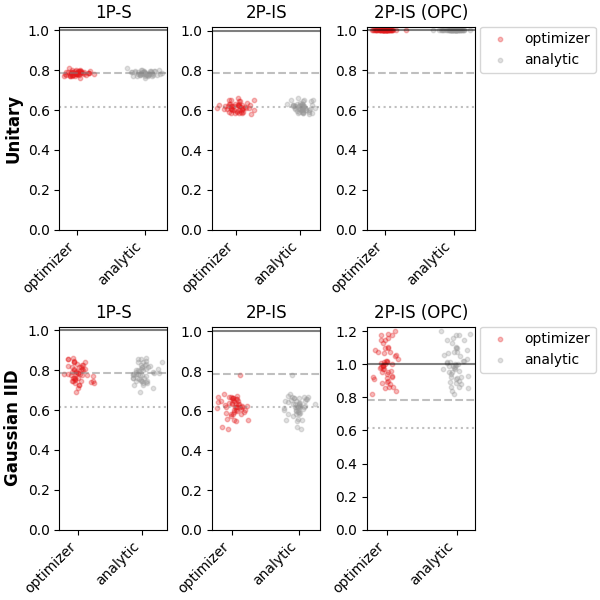

In [35]:
path = glob.glob(rf'{DATA_DIR}\vrs_analytic\*50_tries_analytic*')[-1]
res = QWFSResult(path)
res.print()
fig = res.show_scatterplots(config_names=['1P-S', '2P-IS', '2P-IS (OPC)'], algo_names=['optimizer', 'analytic'], T_names=['Unitary', 'Gaussian IID'])
fig.savefig(rf'G:\My Drive\Projects\ScalingQWFS\Paper\Figures\optimizer_sanity')
plt.show()

## 1.3 adding the FFTs does not change things 
SLM3 configuration will use FFTs, etc. so we make sure that also SLM1 and SLM2 in these slightly more complex configurations show the same results. 

In [24]:
path = glob.glob(rf'{DATA_DIR}\vrs_analytic\*50_tries_with_FFT*')[-1]
res = QWFSResult(path)
res.print()

---- SLM1 ----
-- unitary --
autograd-lbfgs            0.393+-0.39
-- gaus_iid --
autograd-lbfgs            0.391+-0.39

---- SLM2 ----
-- unitary --
autograd-lbfgs            0.312+-0.31
-- gaus_iid --
autograd-lbfgs            0.313+-0.32

---- SLM2-same-mode ----
-- unitary --
autograd-lbfgs            0.500+-0.50
-- gaus_iid --
autograd-lbfgs            0.502+-0.51



# 2) comparing optimizers
See logs in the generate_results notebook. It could be seen that the runtimes of different optimizers scale differently. Most notably:
 
* Simulated annealing, which is supposed to be better at finding a global optimum takes much longer, and scales badly with the size of the system, and does not show consistent better enhancement.
* Using the autograd engine, which uses analytical gradient data, speeds things up significantly, and also achieves better performance.
* The LBFGS and ADAM pytorch optimizers performs similarly.  

# 3) Fig. 3 - results summary
From these results we quote the approximate SLM3 results, and generate Fig. 3.  

C:\Users\ronen\AppData\Local\Temp\ipykernel_14896\3659788006.py:33: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False, constrained_layout=True)
C:\Users\ronen\AppData\Local\Temp\ipykernel_14896\3659788006.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


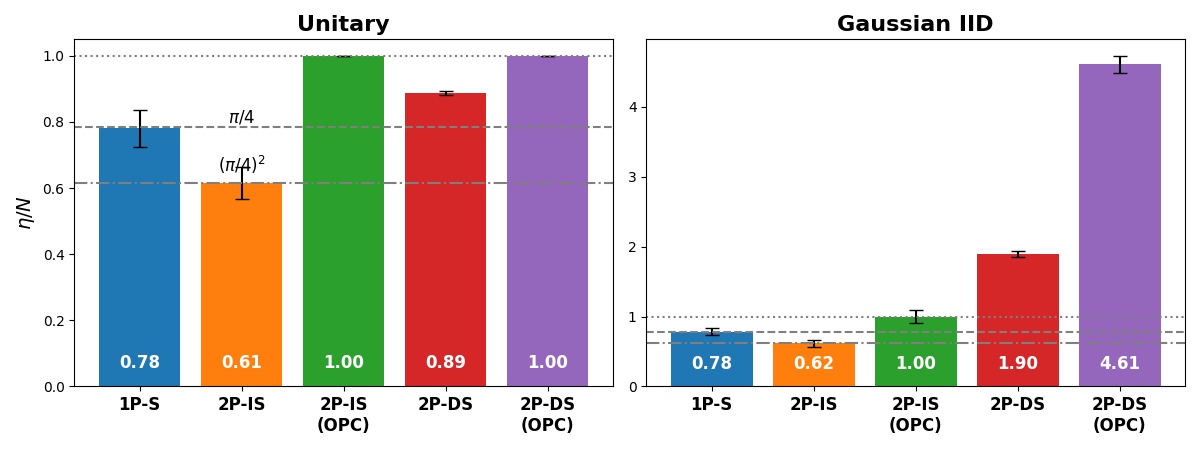

In [26]:
import matplotlib.pyplot as plt
import numpy as np

path = glob.glob(rf'{DATA_DIR}\*all_configs*')[-1]
res = QWFSResult(path)
alg = 'autograd-lbfgs'
alg_ind = np.where(res.algos == 'autograd-lbfgs')[0]

configs = ["SLM1", "SLM2", "SLM2-same-mode", "SLM3", "SLM3-same-mode"]
labels = ["1P-S", "2P-IS", "2P-IS\n(OPC)", "2P-DS", "2P-DS\n(OPC)"]

unitary_data = []
unitary_data_std = []
gaussian_data = []
gaussian_data_std = []

for config in configs:
    T_method_ind = np.where(res.T_methods == 'unitary')[0]
    effs_unitary = res.results[T_method_ind, np.where(res.configs == config)[0], :, alg_ind].squeeze()
    T_method_ind = np.where(res.T_methods == 'gaus_iid')[0]
    effs_gaus = res.results[T_method_ind, np.where(res.configs == config)[0], :, alg_ind].squeeze()
    
    unitary_data.append(effs_unitary.mean())
    unitary_data_std.append(effs_unitary.std()) # / np.sqrt(res.N_tries))
    
    gaussian_data.append(effs_gaus.mean())
    gaussian_data_std.append(effs_gaus.std()) # / np.sqrt(res.N_tries))

x = np.arange(len(labels))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False, constrained_layout=True)

rects1 = ax1.bar(x, unitary_data, color=colors, yerr=unitary_data_std, 
                 error_kw={'ecolor': 'black', 'capsize': 5, 'elinewidth': 1.5})
for rect in rects1:
    height = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width() / 2, 0.045, f'{height:.2f}',
             ha='center', va='bottom', color='white', fontsize=12, fontweight='bold')
    
ax1.axhline(y=np.pi / 4, color='#7f7f7f', linestyle='--', label='$\pi/4$')
ax1.axhline(y=(np.pi / 4) ** 2, color='#7f7f7f', linestyle='-.', label='$(\pi/4)^2$')
ax1.axhline(y=1.0, color='#7f7f7f', linestyle=':', label='$1$')
ax1.set_title('Unitary', fontsize=16, fontweight='bold')
ax1.set_ylabel('$\eta/N$', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=0, ha='center', fontsize=12, fontweight='bold') # rotation = 45
ax1.text(x[1], np.pi / 4, '$\pi/4$', color='black', fontsize=12, va='bottom', ha='center')
ax1.text(x[1], (np.pi / 4) ** 2 + 0.02, '$(\pi/4)^2$', color='black', fontsize=12, va='bottom', ha='center')
# ax1.legend()

rects2 = ax2.bar(x, gaussian_data, color=colors, yerr=gaussian_data_std, 
                 error_kw={'ecolor': 'black', 'capsize': 5, 'elinewidth': 1.5})
for rect in rects2:
    height = rect.get_height()
    ax2.text(rect.get_x() + rect.get_width() / 2, 0.2, f'{height:.2f}',
             ha='center', va='bottom', color='white', fontsize=12, fontweight='bold')

ax2.axhline(y=np.pi / 4, color='#7f7f7f', linestyle='--', label='$\pi/4$')
ax2.axhline(y=(np.pi / 4) ** 2, color='#7f7f7f', linestyle='-.', label='$(\pi/4)^2$')
ax2.axhline(y=1.0, color='#7f7f7f', linestyle=':', label='$1$')
ax2.set_title('Gaussian IID', fontsize=16, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=0, ha='center', fontsize=12, fontweight='bold') # rotation = 45 
# ax2.legend(fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\results_summary.png")

# 4) SLM3 full data example 

I_in.sum()=0.9999999999999999
I_middle_optimized.sum()=1.823794425732777
I_out_optimized.sum()=3.162814231455429
0 500 1000 1500 2000 2500 3000 3500 4000 4500 

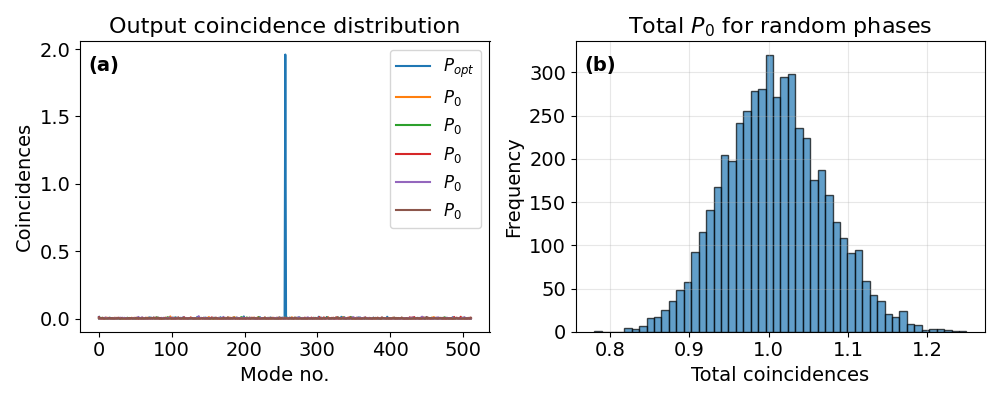

In [33]:
path = glob.glob(rf'{DATA_DIR}\*SLM3_full_data*')[-1]
res = QWFSResult(path)

# Set simulation 
# try_no = np.random.randint(res.N_tries)
try_no = 0
alg = 'autograd-lbfgs'
# config = 'SLM3-same-mode'
config = 'SLM3'
T_method = 'gaus_iid'
# T_method = 'unitary'
alg_ind = np.where(res.algos == alg)[0]
conf_ind = np.where(res.configs == config)[0]
T_method_ind = np.where(res.T_methods == T_method)[0] 
T_ind = res.N_T_methods * try_no + T_method_ind 
T = res.Ts[T_ind].squeeze()
slm_phases = res.best_phases[T_method_ind, conf_ind, try_no, alg_ind].squeeze()
N = len(slm_phases)

sim = QWFSSimulation(N=N)
sim.T = T 
sim.slm_phases = np.exp(1j*slm_phases)
sim.config = config

# get relevant information 
v_out = sim.propagate()
I_out_optimized = np.abs(v_out)**2
I_in = np.abs(sim.v_in)**2
v_middle = sim.T.transpose() @ (sim.slm_phases * sim.v_in)
I_middle_optimized = np.abs(v_middle)**2

print(f'{I_in.sum()=}')
print(f'{I_middle_optimized.sum()=}')
print(f'{I_out_optimized.sum()=}')


tot_Is = []
for i in range(5000):
    if i % 500 == 0:
        print(i, end=' ')
    random_phases = np.random.uniform(0, 2*np.pi, sim.N)
    sim.slm_phases = np.exp(1j*random_phases)
    v_out = sim.propagate()
    I_out = np.abs(v_out)**2
    tot_Is.append(I_out.sum())
    
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(I_out_optimized, label='$P_{opt}$')
for i in range(5):
    random_phases = np.random.uniform(0, 2*np.pi, sim.N)
    sim.slm_phases = np.exp(1j*random_phases)
    v_out = sim.propagate()
    I_out = np.abs(v_out)**2
    ax1.plot(I_out, label='$P_{0}$')

ax1.legend(fontsize=12)
ax1.set_title("Output coincidence distribution", fontsize=16)
ax1.set_xlabel('Mode no.', fontsize=14)
ax1.set_ylabel('Coincidences', fontsize=14)
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, fontsize=14, va='top', ha='left', fontweight='bold')

# Create the histogram
ax2.hist(tot_Is, bins=50, edgecolor='black', alpha=0.7)
ax2.set_title('Total $P_{0}$ for random phases', fontsize=16)
ax2.set_xlabel('Total coincidences', fontsize=14)
ax2.set_ylabel('Frequency', fontsize=14)

show_mean = False
if show_mean:
    ax2.axvline(np.mean(tot_Is), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(tot_Is):.2f}')
    ax2.axvline(np.median(tot_Is), color='green', linestyle='dashed', linewidth=2, label=f'Median: {np.median(tot_Is):.2f}')

ax2.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=14)  
ax2.tick_params(axis='both', labelsize=14)  
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, fontsize=14, va='top', ha='left', fontweight='bold')

# Adjust layout and display
plt.tight_layout()
fig.savefig(rf'G:\My Drive\Projects\ScalingQWFS\Paper\Figures\full_data_example.png')

# 5) 0, $\pi$ phases in SLM3 OPC

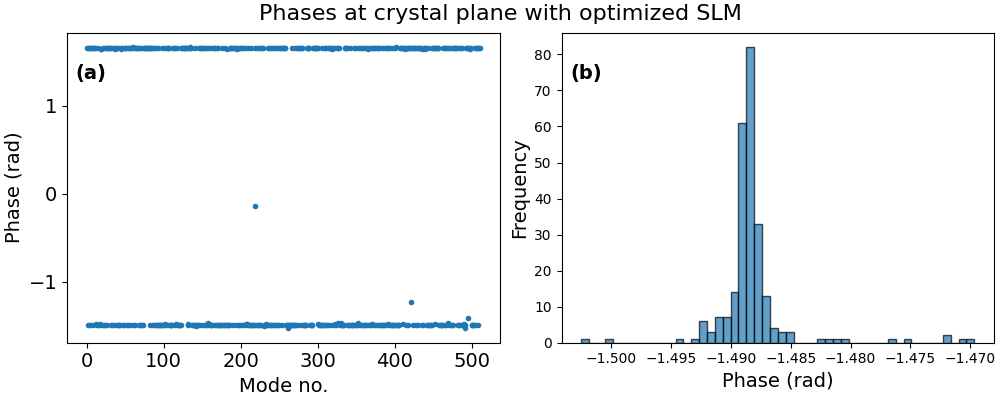

In [12]:
path = glob.glob(rf'{DATA_DIR}\*SLM3_full_data*')[-1]
res = QWFSResult(path)

alg = 'autograd-lbfgs'
config = 'SLM3-same-mode'
# T_method = 'gaus_iid'
T_method = 'unitary'
# try_no = np.random.randint(res.N_tries)
try_no = 0

alg_ind = np.where(res.algos == alg)[0]
conf_ind = np.where(res.configs == config)[0]
T_method_ind = np.where(res.T_methods == T_method)[0]

T_ind = res.N_T_methods * try_no + T_method_ind
T = res.Ts[T_ind].squeeze()
slm_phases = res.best_phases[T_method_ind, conf_ind, try_no, alg_ind].squeeze()
N = len(slm_phases)

sim = QWFSSimulation(N=N)
sim.T = T
sim.slm_phases = np.exp(1j * slm_phases)
sim.config = config

E_middle = sim.T.transpose() @ (sim.slm_phases * sim.v_in)
phases = np.angle(E_middle)
# I_middle = np.abs(E_middle) ** 2
# I_out = np.abs(sim.propagate()) ** 2


fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ax = axes[0]
ax.plot(phases, '.')
fig.suptitle(f'Phases at crystal plane with optimized SLM', fontsize=16)
ax.set_xlabel('Mode no.', fontsize=14)
ax.set_ylabel('Phase (rad)', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.text(0.02, 0.9, '(a)', transform=ax.transAxes, fontsize=14, va='top', ha='left', fontweight='bold')

ax = axes[1] 
ax.hist(phases[(phases > -1.51) & (phases < -1.45)], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Phase (rad)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.text(0.02, 0.9, '(b)', transform=ax.transAxes, fontsize=14, va='top', ha='left', fontweight='bold')

fig.savefig(rf'G:\My Drive\Projects\ScalingQWFS\Paper\Figures\zero_pi_phases.png')

## 5.1) 0, $\pi$ phases in SLM3 OPC with incomplete control

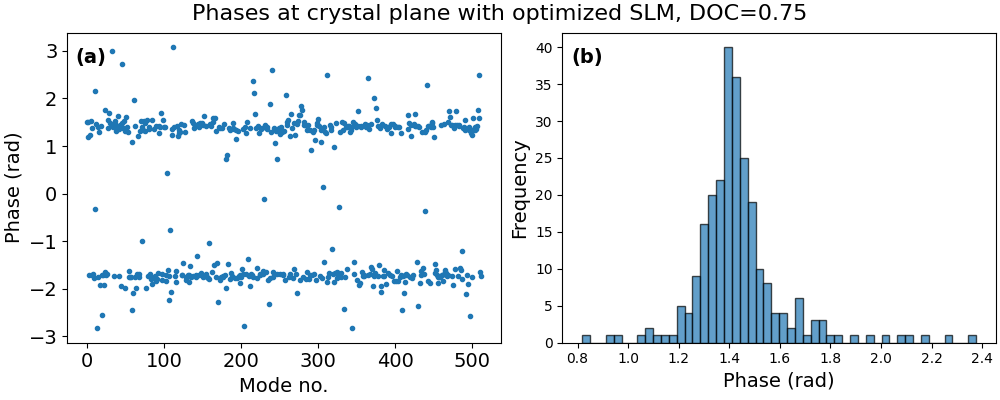

In [14]:
path = glob.glob(rf'{DATA_DIR}\*_SLM3_N_pixels_384_full_data*')[-1]
res = QWFSResult(path)

alg = 'autograd-lbfgs'
config = 'SLM3-same-mode'
# T_method = 'gaus_iid'
T_method = 'unitary'
# try_no = np.random.randint(res.N_tries)
try_no = 0

alg_ind = np.where(res.algos == alg)[0]
conf_ind = np.where(res.configs == config)[0]
T_method_ind = np.where(res.T_methods == T_method)[0]

T_ind = res.N_T_methods * try_no + T_method_ind
T = res.Ts[T_ind].squeeze()
slm_phases = res.best_phases[T_method_ind, conf_ind, try_no, alg_ind].squeeze()
N = len(slm_phases)

sim = QWFSSimulation(N=N)
sim.T = T
sim.slm_phases = np.exp(1j * slm_phases)
sim.config = config

E_middle = sim.T.transpose() @ (sim.slm_phases * sim.v_in)
phases = np.angle(E_middle)
# I_middle = np.abs(E_middle) ** 2
# I_out = np.abs(sim.propagate()) ** 2


fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ax = axes[0]
ax.plot(phases, '.')
fig.suptitle(f'Phases at crystal plane with optimized SLM, DOC=0.75', fontsize=16)
ax.set_xlabel('Mode no.', fontsize=14)
ax.set_ylabel('Phase (rad)', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.text(0.02, 0.95, '(a)', transform=ax.transAxes, fontsize=14, va='top', ha='left', fontweight='bold')

ax = axes[1] 
ax.hist(phases[(phases > 0.8) & (phases < 2.4)], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Phase (rad)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.text(0.02, 0.95, '(b)', transform=ax.transAxes, fontsize=14, va='top', ha='left', fontweight='bold')

fig.savefig(rf'G:\My Drive\Projects\ScalingQWFS\Paper\Figures\zero_pi_phases_incomplete_control.png')

# 6) N-dependence of SLM3

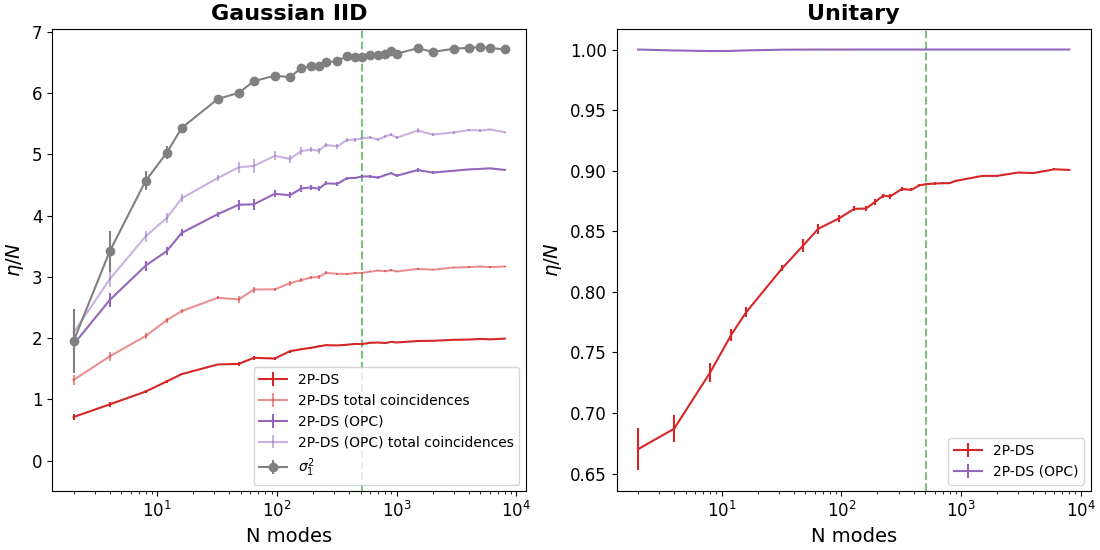

In [16]:
paths = glob.glob(rf'{DATA_DIR}\N_dep\*_Nmodes_*')
ress = [QWFSResult(path) for path in paths]
Ns = np.array([re.findall('.*Nmodes_(\d+).npz', path)[0] for path in paths]).astype(float)
Ns, ress = list(zip(*sorted(zip(Ns, ress), key=lambda pair: pair[0])))
Ns, ress = list(Ns), list(ress)
# Ns, ress = Ns[:-1], ress[:-1]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 2, constrained_layout=True, figsize=(11, 5.5))

for ax, T_method in zip(axes, ress[0].T_methods[::-1]):
    effs_SLM3 = np.zeros_like(Ns)
    stds_SLM3 = np.zeros_like(Ns)
    tot_I_outs_SLM3 = np.zeros_like(Ns)
    tot_I_outs_std_SLM3 = np.zeros_like(Ns)
    effs_SLM3_OPC = np.zeros_like(Ns)
    stds_SLM3_OPC = np.zeros_like(Ns)
    tot_I_outs_SLM3_OPC = np.zeros_like(Ns)
    tot_I_outs_std_SLM3_OPC = np.zeros_like(Ns)
    max_SVDs = np.zeros_like(Ns)
    max_SVDs_std = np.zeros_like(Ns)

    alg_ind = np.where(ress[0].algos == 'autograd-lbfgs')[0]
    T_method_ind = np.where(ress[0].T_methods == T_method)[0]

    for i, N in enumerate(Ns):
        res = ress[i]
        effs = res.results[T_method_ind, np.where(res.configs == 'SLM3')[0], :, alg_ind].squeeze()
        effs = effs[effs != 0]
        effs_SLM3[i] = effs.mean(); stds_SLM3[i] = effs.std() / np.sqrt(res.results.shape[2])
        
        tot_I_outs = res.tot_power_results[T_method_ind, np.where(res.configs == 'SLM3')[0], :, alg_ind].squeeze()
        tot_I_outs = tot_I_outs[tot_I_outs != 0]
        tot_I_outs_SLM3[i] = tot_I_outs.mean(); tot_I_outs_std_SLM3[i] = tot_I_outs.std() / np.sqrt(res.results.shape[2])
        
        effs = res.results[T_method_ind, np.where(res.configs == 'SLM3-same-mode')[0], :, alg_ind].squeeze()
        effs = effs[effs != 0]
        tot_I_outs = res.tot_power_results[T_method_ind, np.where(res.configs == 'SLM3-same-mode')[0], :, alg_ind].squeeze()
        tot_I_outs = tot_I_outs[tot_I_outs != 0]
        effs_SLM3_OPC[i] = effs.mean(); stds_SLM3_OPC[i] = effs.std() / np.sqrt(res.results.shape[2])
        tot_I_outs_SLM3_OPC[i] = tot_I_outs.mean(); tot_I_outs_std_SLM3_OPC[i] = tot_I_outs.std() / np.sqrt(res.results.shape[2])

        if T_method == 'gaus_iid':
            T_method_no = np.where(ress[0].T_methods == 'gaus_iid')[0][0]
            these_svds = res.max_SVDs[T_method_no::2]
            max_SVDs[i] = these_svds.mean()**2 
            max_SVDs_std[i] = these_svds.std()**2 
        
    times_N = False
    if times_N:
        effs_SLM3 *= Ns
        effs_SLM3_OPC *= Ns
        max_SVDs *= Ns
        tot_I_outs_SLM3 *= Ns
        tot_I_outs_SLM3_OPC *= Ns
    
    if not T_method == 'gaus_iid':
        lines = ax.errorbar(Ns, effs_SLM3, stds_SLM3, label='2P-DS', color=colors[3])
        lines_OPC = ax.errorbar(Ns, effs_SLM3_OPC, stds_SLM3_OPC, label='2P-DS (OPC)', color=colors[4])
        ax.legend(loc='lower right')
        ax.set_title(f'Unitary', fontsize=16, fontweight='bold')
    else:       
        lines = ax.errorbar(Ns, effs_SLM3, stds_SLM3, label='2P-DS', color=colors[3])
        ax.errorbar(Ns, tot_I_outs_SLM3, tot_I_outs_std_SLM3, label='2P-DS total coincidences', color=lines[0].get_c(), alpha=0.5)
        lines_OPC = ax.errorbar(Ns, effs_SLM3_OPC, stds_SLM3_OPC, label='2P-DS (OPC)', color=colors[4])
        ax.errorbar(Ns, tot_I_outs_SLM3_OPC, tot_I_outs_std_SLM3_OPC, label='2P-DS (OPC) total coincidences', color=lines_OPC[0].get_c(), alpha=0.5)
        ax.errorbar(Ns, max_SVDs, max_SVDs_std, label=r'$\sigma_{1}^2$', marker='o', color='gray')
        # ax.legend(loc='upper center', bbox_to_anchor=(0.1, 0.9), ncol=2)
        ax.legend(loc='lower right')
        ax.set_ylim((-0.5, None))
        ax.set_title(f'Gaussian IID', fontsize=16, fontweight='bold')

    ax.set_xlabel('N modes', fontsize=14)
    ax.set_ylabel('$\eta/N$', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)  
    ax.axvline(512, linestyle='--', color='g', alpha=0.5)

    ax.set_xscale('log')
    
fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\N_dependence.png")

# 7) incopmlete control 

In [78]:
from scipy.optimize import curve_fit

def incomplete_control(small_control=False, thin=False, linestyle='-', marker='.'):
    if not thin:
        paths = glob.glob(rf'{DATA_DIR}\incomplete_control\2025_01*_Npixels_*')
    else:
        paths = glob.glob(rf'{DATA_DIR}\incomplete_control\thin\2025_04*_Npixels_*')
        
    ress = [QWFSResult(path) for path in paths]
    N_pixs = np.array([re.findall('.*Npixels_(\d+).npz', path)[0] for path in paths]).astype(float)
    N_pixs, ress = list(zip(*sorted(zip(N_pixs, ress), key=lambda pair: pair[0])))
    N_pixs, ress = np.array(N_pixs), np.array(ress)
    DOCs = N_pixs / ress[0].N_modes
    
    if not thin:
        fig, axes = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 5))
    else:
        fig, axes = plt.subplots(1, 1, constrained_layout=True, figsize=(6, 5))
        axes = [axes]
    
    for ax, T_method in zip(axes, ress[0].T_methods):
        N_tries = ress[0].N_tries
        effs_SLM1 = np.zeros_like(N_pixs)
        stds_SLM1 = np.zeros_like(N_pixs)
        effs_SLM2 = np.zeros_like(N_pixs)
        stds_SLM2 = np.zeros_like(N_pixs)
        effs_SLM2_OPC = np.zeros_like(N_pixs)
        stds_SLM2_OPC = np.zeros_like(N_pixs)
        effs_SLM3 = np.zeros_like(N_pixs)
        stds_SLM3 = np.zeros_like(N_pixs)
        effs_SLM3_OPC = np.zeros_like(N_pixs)
        stds_SLM3_OPC = np.zeros_like(N_pixs)
        alg_ind = np.where(ress[0].algos == 'autograd-lbfgs')[0]
        T_method_ind = np.where(ress[0].T_methods == T_method)[0]
    
        for i, DOC in enumerate(DOCs):
            res = ress[i]       
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM1')[0], :, alg_ind].squeeze()
            effs_SLM1[i] = effs.mean(); stds_SLM1[i] = effs.std() / np.sqrt(N_tries)
            
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM2')[0], :, alg_ind].squeeze()
            effs_SLM2[i] = effs.mean(); stds_SLM2[i] = effs.std() / np.sqrt(N_tries)
    
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM2-same-mode')[0], :, alg_ind].squeeze()
            effs_SLM2_OPC[i] = effs.mean(); stds_SLM2_OPC[i] = effs.std() / np.sqrt(N_tries)
            
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM3')[0], :, alg_ind].squeeze()
            effs_SLM3[i] = effs.mean(); stds_SLM3[i] = effs.std() / np.sqrt(N_tries)
    
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM3-same-mode')[0], :, alg_ind].squeeze()
            effs_SLM3_OPC[i] = effs.mean(); stds_SLM3_OPC[i] = effs.std() / np.sqrt(N_tries)
            
        lw = 2.5
        lines_SLM1 = ax.errorbar(DOCs, effs_SLM1, stds_SLM1, label='1P-S', lw=lw, capsize=1, linestyle=linestyle, marker=marker)
        lines_SLM2 = ax.errorbar(DOCs, effs_SLM2, stds_SLM2, label='2P-IS', lw=lw, linestyle=linestyle, marker=marker)
        lines_SLM2_OPC = ax.errorbar(DOCs, effs_SLM2_OPC, stds_SLM2_OPC, label='2P-IS (OPC)', lw=lw, linestyle=linestyle, marker=marker)
        lines_SLM3 = ax.errorbar(DOCs, effs_SLM3, stds_SLM3, label='2P-DS', lw=lw, linestyle=linestyle, marker=marker)
        lines_SLM3_OPC = ax.errorbar(DOCs, effs_SLM3_OPC, stds_SLM3_OPC, label='2P-DS (OPC)', lw=lw, linestyle=linestyle, marker=marker)
            
        ax.plot([0, 1], [0, np.pi/4], color=lines_SLM1[0].get_c(), linestyle='--', alpha=0.5)
        if not small_control:
            if not thin:
                ax.plot([0, 1], [0, (np.pi/4)**2], color=lines_SLM2[0].get_c(), linestyle='--', alpha=0.5)
            ax.plot([0, 1], [0, 1], color=lines_SLM2_OPC[0].get_c(), linestyle='--', alpha=0.5)
            ax.plot([0, 1], [0, effs_SLM3.max()], color=lines_SLM3[0].get_c(), linestyle='--', alpha=0.5)
            if T_method == 'gaus_iid':
                ax.plot([0, 1], [0, effs_SLM3_OPC.max()], color=lines_SLM3_OPC[0].get_c(), linestyle='--', alpha=0.5)
            ax.set_xlim((-0.01, None))
            ax.set_ylim((-0.01, None))

        else:
            ax.plot([0, 1], [0, np.pi/2], color=lines_SLM2_OPC[0].get_c(), linestyle='--', alpha=0.5)            
            n_points = 9
            p, cov = curve_fit(lambda x, a, b: a*x+b, DOCs[:n_points], effs_SLM3[:n_points], bounds=(-1, 5), loss='huber')
            a3, b3 = p[0], p[1]
            p, cov_opc = curve_fit(lambda x, a, b: a*x+b, DOCs[:n_points], effs_SLM3_OPC[:n_points], bounds=(-1, 5), loss='huber')
            a3opc, b3opc = p[0], p[1]
            ax.plot([0, 1], [b3, b3+a3], color=lines_SLM3[0].get_c(), linestyle='--', alpha=0.5)
            ax.plot([0, 1], [b3opc, b3opc+a3opc], color=lines_SLM3_OPC[0].get_c(), linestyle='--', alpha=0.5)
            print(f'{T_method=}: {a3=:.3f}+-{cov[0, 0]:.3f}; {b3=:.3f} +- {cov[1, 1]:.3f}')
            print(f'{T_method=}: {a3opc=:.3f}+-{cov_opc[0, 0]:.3f}; {b3opc=:.3f} +- {cov_opc[1, 1]:.3f}')

            ax.set_xlim((-0.001, 0.15))
            ax.set_ylim((-0.001, 0.15))
        ax.legend()
        ax.set_xlabel('Degree of control', fontsize=16)
        ax.set_ylabel('$\eta/N$', fontsize=16)
        if T_method == 'gaus_iid':
            ax.set_title(f'Gaussian IID', fontweight='bold', fontsize=16)
        elif T_method == 'unitary':
            ax.set_title(f'Unitary', fontweight='bold', fontsize=16)
        elif T_method == 'thin':
            ax.set_title(f'Thin diffuser', fontweight='bold', fontsize=16)
            
        
        if not thin:
            ax.axhline(y=np.pi/4, color='gray', linestyle='--', alpha=0.5)
            ax.axhline(y=(np.pi / 4) ** 2, color='gray', linestyle=':', alpha=0.5)
        ax.axhline(y=1, color='black', linestyle='-', alpha=0.5)
        ax.tick_params(axis='both', labelsize=12) 
    
    if not thin:
        if small_control:
            fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\small_control.png")
        else:
            fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\incomplete_control.png")
    else:
        fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\thin_diffuser.png")
        
        

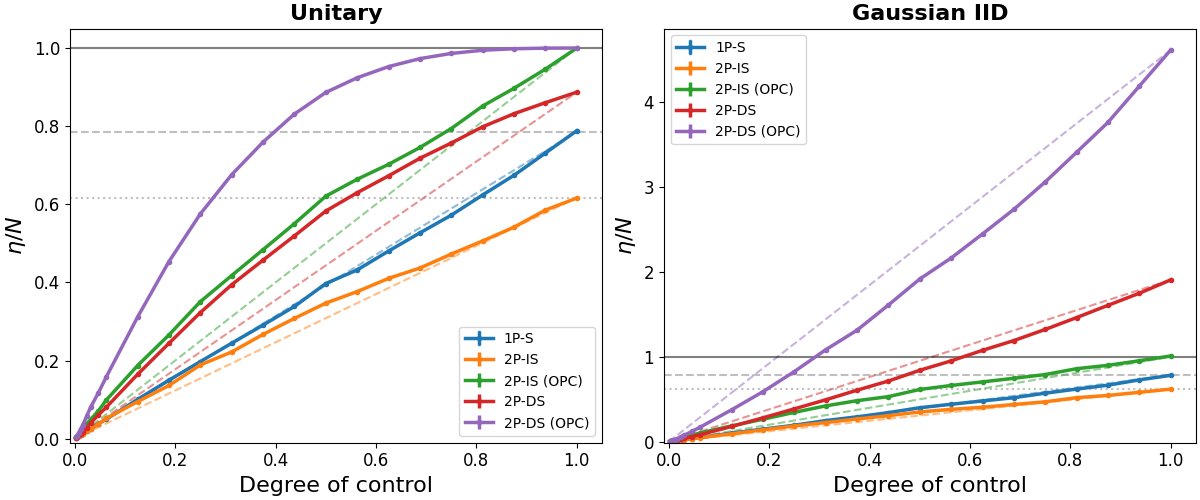

In [81]:
incomplete_control(small_control=False, linestyle='-')

## 7.1 little control limit 

T_method='unitary': a3=1.318+-0.000; b3=-0.002 +- 0.000
T_method='unitary': a3opc=2.587+-0.001; b3opc=-0.004 +- 0.000
T_method='gaus_iid': a3=1.354+-0.000; b3=-0.003 +- 0.000
T_method='gaus_iid': a3opc=2.777+-0.003; b3opc=-0.006 +- 0.000


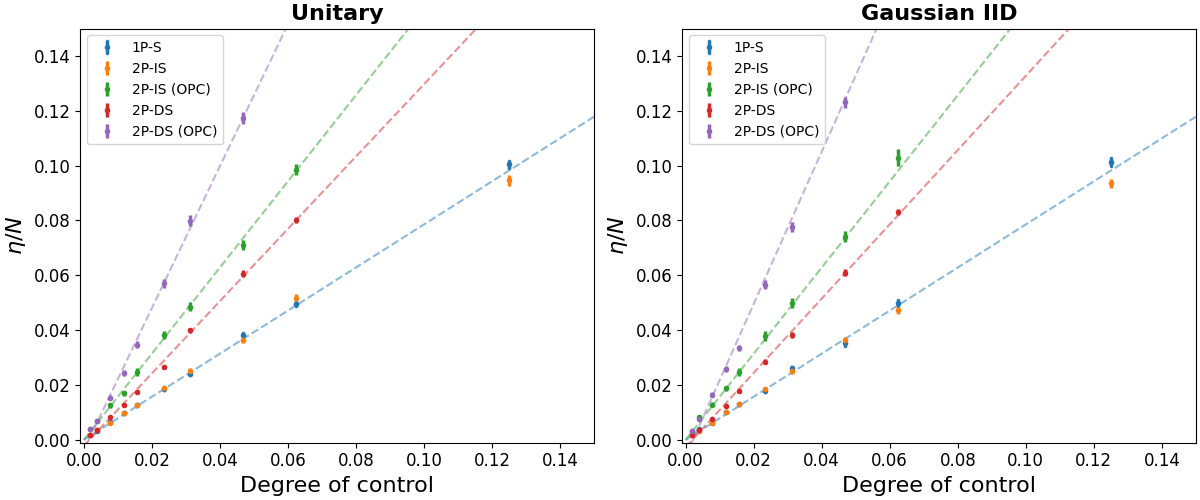

In [4]:
incomplete_control(small_control=True, linestyle='none')

## 7.2 thin diffuser

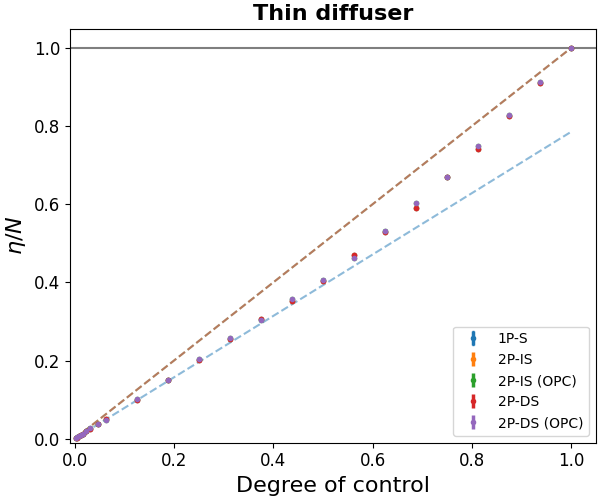

In [5]:
incomplete_control(small_control=False, thin=True, linestyle='none', marker='.')

# 8) Schmidt number 

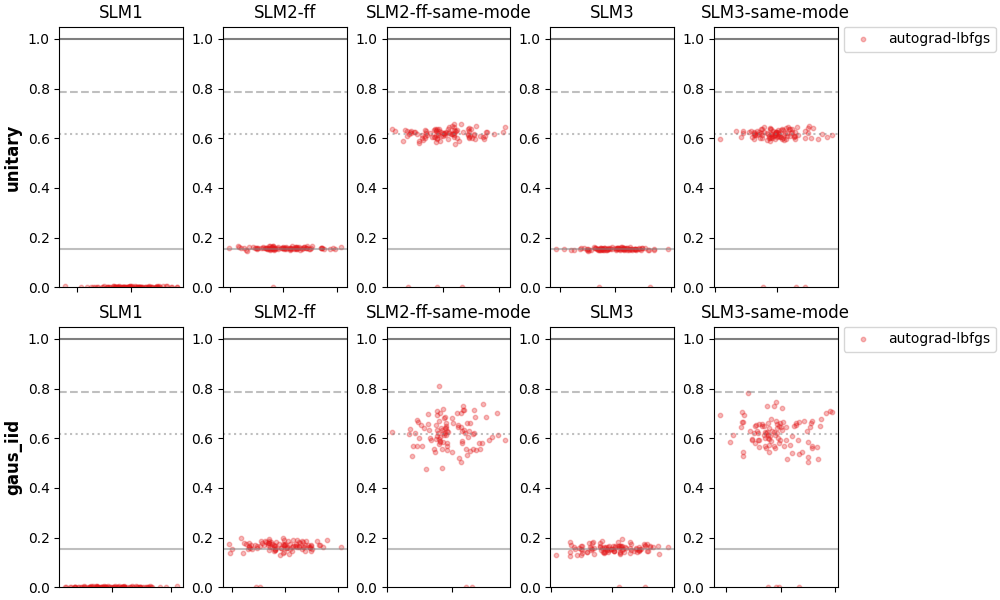

In [7]:
from qwfs.qwfs_result import QWFSResult
import os 
DATA_DIR = os.path.join(os.path.abspath(os.path.curdir), 'data')
path = os.path.join(DATA_DIR, 'schmidt', '2025_08_07_15_00_45_K=1_100_tries.npz')
res = QWFSResult(path)
fig = res.show_scatterplots()
# fig.show()
fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\Schmidt_1.png")

# res = QWFSResult(path)
# fig = res.show_scatterplots(mul_factor=res.N_modes)
# fig.show()
# fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\Schmidt_1_SLM1.png")
# This shows the output powers. In the SLM2-ff and SLM3 cases, the enhancement comes by dividing by the average intensity, which is 1/N^2, as we show below. In the SLM1 configuration, we get the output power, which fluctuates a lot between realizations (depending on the specific output speckle grain we choose), but on average is enhanced like pi/4 * N.  

In [8]:
print(f'{np.pi/4=}')
res.print(mul_SLM1=True)
print(f'{(np.pi/4)**2=}')
print(f'{(np.pi/8)**2=}')

np.pi/4=0.7853981633974483
---- SLM1 ----
-- unitary --
autograd-lbfgs            0.866+-0.78
-- gaus_iid --
autograd-lbfgs            0.883+-0.86

---- SLM2-ff ----
-- unitary --
autograd-lbfgs            0.157+-0.02
-- gaus_iid --
autograd-lbfgs            0.164+-0.03

---- SLM2-ff-same-mode ----
-- unitary --
autograd-lbfgs            0.600+-0.11
-- gaus_iid --
autograd-lbfgs            0.611+-0.10

---- SLM3 ----
-- unitary --
autograd-lbfgs            0.152+-0.02
-- gaus_iid --
autograd-lbfgs            0.153+-0.03

---- SLM3-same-mode ----
-- unitary --
autograd-lbfgs            0.599+-0.11
-- gaus_iid --
autograd-lbfgs            0.598+-0.13

(np.pi/4)**2=0.6168502750680849
(np.pi/8)**2=0.15421256876702122


In [9]:
# The average output power is K/N^2 
from qwfs.qwfs_simulation import QWFSSimulation
N = N_modes = 512
s = QWFSSimulation(N=N_modes, T_method='unitary')
rank = 5
s.set_schmidt_rank(rank)
means = []
for i in range(30):
    s.reset_T()
    v = s.propagate()
    I = np.abs(v) ** 2
    means.append(I.mean())
mean = np.array(means).mean()
print(I.mean())
print(f'{rank/N**2=}')

1.6303563289452845e-05
rank/N**2=1.9073486328125e-05


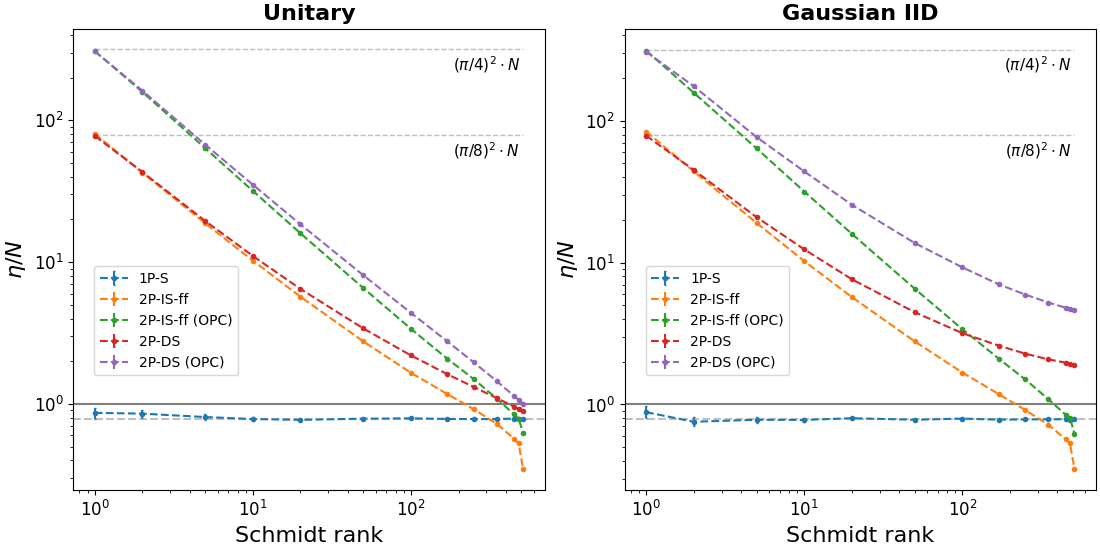

In [5]:
import glob
from qwfs.qwfs_result import QWFSResult
import os 
import re
DATA_DIR = os.path.join(os.path.abspath(os.path.curdir), 'data')
linestyle='--'
marker='.'

def show_schmidt(normalize=True, log_scale=True):
    paths = glob.glob(rf'{DATA_DIR}\schmidt\*K=*')
    ress = [QWFSResult(path) for path in paths]
    ranks = np.array([re.findall('.*K=(\d+)_.*.npz', path)[0] for path in paths]).astype(float)
    ranks, ress = list(zip(*sorted(zip(ranks, ress), key=lambda pair: pair[0])))
    ranks, ress = list(ranks), list(ress)
    # Ns, ress = Ns[:-1], ress[:-1]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    fig, axes = plt.subplots(1, 2, constrained_layout=True, figsize=(11, 5.5))
    
    for ax, T_method in zip(axes, ress[0].T_methods):
        N_tries = ress[0].N_tries
        effs_SLM1 = np.zeros_like(ranks)
        stds_SLM1 = np.zeros_like(ranks)
        effs_SLM2 = np.zeros_like(ranks)
        stds_SLM2 = np.zeros_like(ranks)
        effs_SLM2_OPC = np.zeros_like(ranks)
        stds_SLM2_OPC = np.zeros_like(ranks)
        effs_SLM3 = np.zeros_like(ranks)
        stds_SLM3 = np.zeros_like(ranks)
        effs_SLM3_OPC = np.zeros_like(ranks)
        stds_SLM3_OPC = np.zeros_like(ranks)
        alg_ind = np.where(ress[0].algos == 'autograd-lbfgs')[0]
        T_method_ind = np.where(ress[0].T_methods == T_method)[0]
    
        for i, rank in enumerate(ranks):
            res = ress[i]       
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM1')[0], :, alg_ind].squeeze()
            effs_SLM1[i] = effs.mean(); stds_SLM1[i] = effs.std() / np.sqrt(N_tries)
            
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM2-ff')[0], :, alg_ind].squeeze()
            effs_SLM2[i] = effs.mean(); stds_SLM2[i] = effs.std() / np.sqrt(N_tries)
    
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM2-ff-same-mode')[0], :, alg_ind].squeeze()
            effs_SLM2_OPC[i] = effs.mean(); stds_SLM2_OPC[i] = effs.std() / np.sqrt(N_tries)
            
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM3')[0], :, alg_ind].squeeze()
            effs_SLM3[i] = effs.mean(); stds_SLM3[i] = effs.std() / np.sqrt(N_tries)
    
            effs = res.results[T_method_ind, np.where(res.configs == 'SLM3-same-mode')[0], :, alg_ind].squeeze()
            effs_SLM3_OPC[i] = effs.mean(); stds_SLM3_OPC[i] = effs.std() / np.sqrt(N_tries)
            
        # These effs are the power after. The power before optimization is K/N^2. Normalizing by K/N, to keep the convention of eta/N similar to other figures. At K=1 the enhancement is quadratic with N, so it is indeed much larger. In K=N it is linear with N and returns to original results of O(1). SLM1 is linear with N all along. 
        if normalize:
            effs_SLM1 /= (ranks/res.N_modes)
            stds_SLM1 = np.array(stds_SLM1) / (ranks/res.N_modes)
            effs_SLM2 /= (ranks/res.N_modes)
            stds_SLM2 = np.array(stds_SLM2) / (ranks/res.N_modes)
            effs_SLM2_OPC /= (ranks/res.N_modes)
            stds_SLM2_OPC = np.array(stds_SLM2_OPC) / (ranks/res.N_modes)
            effs_SLM3 /= (ranks/res.N_modes)
            stds_SLM3 = np.array(stds_SLM3) / (ranks/res.N_modes)
            effs_SLM3_OPC /= (ranks/res.N_modes)
            stds_SLM3_OPC = np.array(stds_SLM3_OPC) / (ranks/res.N_modes)
            
            ax.plot((1, res.N_modes), (res.N_modes*(np.pi/8)**2, res.N_modes*(np.pi/8)**2), '--', color='gray', linewidth=1, alpha=0.5)
            ax.plot((1, res.N_modes), (res.N_modes*(np.pi/4)**2, res.N_modes*(np.pi/4)**2), '--', color='gray', linewidth=1, alpha=0.5)
            ax.text(300, 210, '$(\pi/4)^2\cdot N$', color='black', fontsize=11, va='bottom', ha='center')
            ax.text(300, 52, '$(\pi/8)^2\cdot N$', color='black', fontsize=11, va='bottom', ha='center')
            
        lw = 1.5
        ax.errorbar(ranks, effs_SLM1, stds_SLM1, label='1P-S', lw=lw, capsize=1, linestyle=linestyle, marker=marker)
        ax.errorbar(ranks, effs_SLM2, stds_SLM2, label='2P-IS-ff', lw=lw, linestyle=linestyle, marker=marker)
        ax.errorbar(ranks, effs_SLM2_OPC, stds_SLM2_OPC, label='2P-IS-ff (OPC)', lw=lw, linestyle=linestyle, marker=marker)
        ax.errorbar(ranks, effs_SLM3, stds_SLM3, label='2P-DS', lw=lw, linestyle=linestyle, marker=marker)
        ax.errorbar(ranks, effs_SLM3_OPC, stds_SLM3_OPC, label='2P-DS (OPC)', lw=lw, linestyle=linestyle, marker=marker)
            
        if log_scale:
            ax.set_xscale('log')
            ax.set_yscale('log')
        else:
            ax.set_xlim((-0.01, None))
            ax.set_ylim((-0.1, None))
        
        ax.legend(loc='upper left', bbox_to_anchor=(0.03, 0.5))
        ax.set_xlabel('Schmidt rank', fontsize=16)
        if normalize:
            ax.set_ylabel('$\eta/N$', fontsize=16)
        else:
            ax.set_ylabel('$I_{out}$', fontsize=16)
            
        if T_method == 'gaus_iid':
            ax.set_title(f'Gaussian IID', fontweight='bold', fontsize=16)
        elif T_method == 'unitary':
            ax.set_title(f'Unitary', fontweight='bold', fontsize=16)
              
        ax.axhline(y=np.pi/4, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(y=1, color='black', linestyle='-', alpha=0.5)
        ax.tick_params(axis='both', labelsize=12) 
    
    # fig.show()
    fig.savefig(r"G:\My Drive\Projects\ScalingQWFS\Paper\Figures\Schmidt.png")

# Show total powers 
# show_schmidt(normalize=False, log_scale=False)
# Show enhancements (scaling changes from quadratic in N to linear, so need log scale) 
show_schmidt(normalize=True, log_scale=True)

In [11]:
# The result for the 2P-IS-ff configuration at K=512 is the same as the result for 2P-IS configuration with DOC=0.5 (N_pixels=256) 
path = glob.glob(rf'{DATA_DIR}\schmidt\*K=512*')[0]
res = QWFSResult(path)
res.print(which_configs=['SLM2-ff', 'SLM2-ff-same-mode'])
print('================')
path = glob.glob(rf'{DATA_DIR}\incomplete_control\2025_01*_Npixels_256*')[0]
res = QWFSResult(path)
res.print(which_configs=['SLM2', 'SLM2-same-mode'])

---- SLM2-ff ----
-- unitary --
autograd-lbfgs            0.347+-0.02
-- gaus_iid --
autograd-lbfgs            0.352+-0.03

---- SLM2-ff-same-mode ----
-- unitary --
autograd-lbfgs            0.621+-0.03
-- gaus_iid --
autograd-lbfgs            0.621+-0.07

---- SLM2 ----
-- unitary --
autograd-lbfgs            0.347+-0.02
-- gaus_iid --
autograd-lbfgs            0.351+-0.02

---- SLM2-same-mode ----
-- unitary --
autograd-lbfgs            0.621+-0.03
-- gaus_iid --
autograd-lbfgs            0.616+-0.05

